<a href="https://colab.research.google.com/github/AliceSantoro/Kohonen/blob/main/2D_over_3Dipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rete di Kohonen con topologia 2D su uno spazio a 3D

## Caricamento dei moduli necessari

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import random
import math
from tqdm import tqdm # progress bar
from mpl_toolkits.mplot3d import axes3d

## Punti di ancoraggio
Definizione di funzioni che generano un certo numero di punti in uno spazio 3D con diverse distribuzioni

-`sfera` con distribuzione uniforme

-`sfera` con distribuzione uniforme centrata al polo Nord

In [ ]:
def sphere(quanti):
  rs=(np.random.uniform(0,1,quanti))**(1/3)
  phis=np.random.uniform(0,np.pi,quanti)
  thetas=np.random.uniform(0,2*np.pi,quanti)
  x=np.sin(phis)*np.cos(thetas)
  y=np.sin(phis)*np.sin(thetas)
  z=np.cos(phis)
  return x,y,z

In [ ]:

def sphere_northpole(quanti):
  rs=np.random.uniform(0,1,quanti)
  phis=np.random.uniform(0,np.pi/2,quanti)
  thetas=np.random.uniform(0,2*np.pi,quanti)
  x=np.sin(phis)*np.cos(thetas)
  y=np.sin(phis)*np.sin(thetas)
  z=np.cos(phis)
  return x,y,z

## Parametri
`n*n` neuroni, , `m` punti di esempio. I neuroni devono essere **meno** dei punti di esempio, per evitare l'overfitting.

In [ ]:
n=10
m=100

## Genero le coordinate x e y per `m` punti con la distribuzione che ho scelto

In [ ]:
xtest,ytest,ztest = sphere(m)

In [ ]:
xtest,ytest,ztest = sphere_northpole(m)

##Plot scatter dei punti

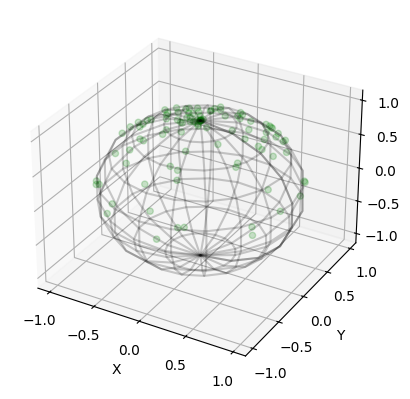

In [ ]:

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(xtest, ytest, ztest, c='g', alpha = 0.2)

#creo una griglia sferica
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
x = np.cos(u) * np.sin(v)
y = np.sin(u) * np.sin(v)
z = np.cos(v)

# Plot the sphere
ax.plot_wireframe(x, y, z, color='black', alpha = 0.2)

# etichetto gli assi
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

##Genero il reticolo discreto bidimensionale di neuroni

I punti sono a 3 dimensioni, quindi mi servono `n` coordinate in 3D, che chiamo  `w_0`, `w_1` e `w_2`.

 La topologia e' a 2 dimensioni, quindi le `w_0`, `w_1` e `w_2` sono 2D (matrici).

In [ ]:
w_0 = 0.1*np.random.rand(n,n)
w_1 = 0.1*np.random.rand(n,n)
w_2 = 0.1*np.random.rand(n,n)

## Rappresentazione della rete prima dell'apprendimento


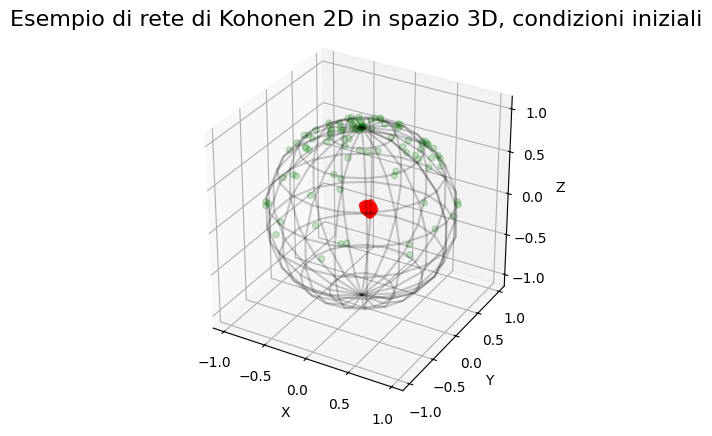

In [ ]:
#faccio il plot dello stato iniziale della rete

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')


ax.scatter(xtest, ytest, ztest, c='g', alpha = 0.2)
ax.scatter(w_0,w_1,w_2, c='r',marker='o')
for i in range(n):
        ax.plot(w_0[i,:],w_1[i,:],w_2[i,:],'k',linewidth=1)
        ax.plot(w_0[:,i],w_1[:,i],w_2[:,i],'k',linewidth=1)

ax.set_title('Esempio di rete di Kohonen 2D in spazio 3D, condizioni iniziali',fontsize=16)

#creo una griglia sferica
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
x = np.cos(u) * np.sin(v)
y = np.sin(u) * np.sin(v)
z = np.cos(v)

# Plot
ax.plot_wireframe(x, y, z, color='black', alpha = 0.2)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_aspect('equal')


plt.show()

## Ottimizzazione (training) della rete


In [ ]:
# scelgo il numero di passi di apprendimento
# 1 step = 1000 updates
nsteps = 100

eps0=0.15
sigma0=18

# alloco dello spazio per salvare i pesi ad ogni step
w_0_t = np.empty((n,n,nsteps),dtype=float)
w_1_t = np.empty_like(w_0_t)
w_2_t = np.empty_like(w_0_t)

print("\n**** Training iniziato !!! ****\n")

# condizioni iniziali al primo step

w_0_t[:,:,0] = w_0
w_1_t[:,:,0] = w_1
w_2_t[:,:,0] = w_2

# apprendimento dal primo step in avanti

for _t in tqdm(range(nsteps-1)):
    eps = eps0 * (0.99**_t)
    sigma = sigma0 * (0.96**_t)
    t = _t+1 # prossimo timestep
    # inizializzo dal timestep precedente
    w_0_t[:,:,t] = w_0_t[:,:,t-1]
    w_1_t[:,:,t] = w_1_t[:,:,t-1]
    w_2_t[:,:,t] = w_2_t[:,:,t-1]
    # somministro 1000 punti di esempio per ogni passo
    for _ in range(1000):
      # scelgo randomicamente un punto di esempio
      exi = np.random.randint(m)
      # calcolo la matrice delle distanze
      dist = ((xtest[exi]-w_0_t[:,:,t])**2+
              (ytest[exi]-w_1_t[:,:,t])**2+
              (ztest[exi]-w_2_t[:,:,t])**2)
      # trovo l'indice del neurone vincitore
      min_dist_idx = np.unravel_index(np.argmin(dist, axis=None), dist.shape)

      ineigh = min_dist_idx[0]
      jneigh = min_dist_idx[1]


      # faccio l'updatedi TUTTI i pesi
      for i in range(n):
        for j in range(n):
          f_up=np.exp(-((i-ineigh)**2+(j-jneigh)**2)/(2*sigma**2))
          w_0_t[i,j,t]=w_0_t[i,j,t]+eps*f_up*(xtest[exi]-w_0_t[i,j,t])
          w_1_t[i,j,t]=w_1_t[i,j,t]+eps*f_up*(ytest[exi]-w_1_t[i,j,t])
          w_2_t[i,j,t]=w_2_t[i,j,t]+eps*f_up*(ztest[exi]-w_2_t[i,j,t])

print(f"\n**** Training completato per {nsteps} steps ****\n")


**** Training iniziato !!! ****



100%|██████████| 99/99 [01:30<00:00,  1.09it/s]


**** Training completato per 100 steps ****



## Rete allo stato finale

<Axes3D: title={'center': 'rete di Kohonen 2D in spazio 3D, condizioni finali'}>

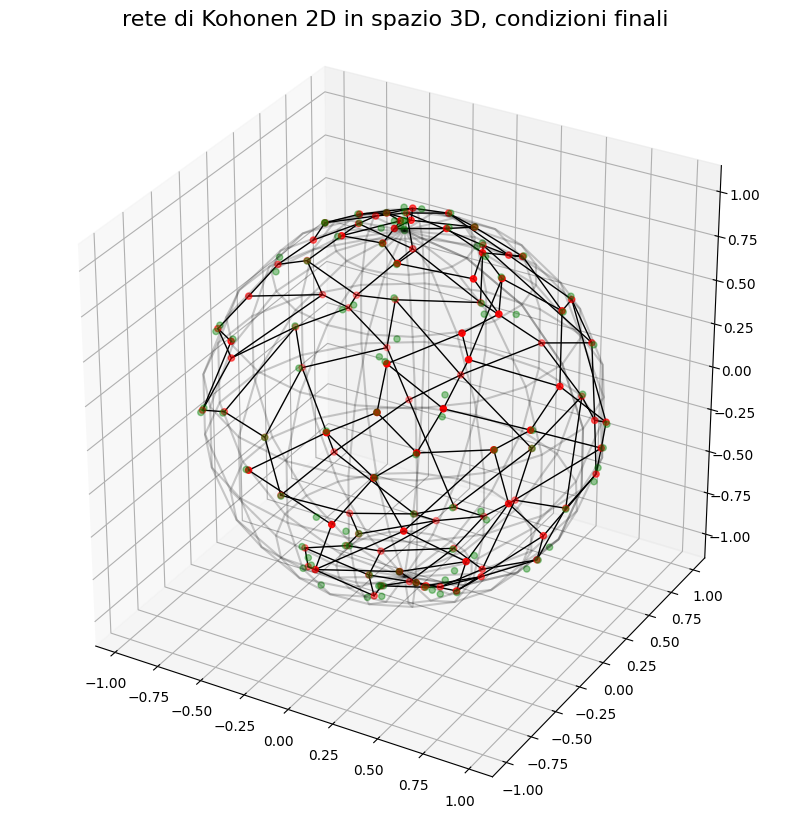

In [ ]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.scatter(xtest,ytest,ztest, c='g',alpha=0.4)
ax.scatter(w_0_t[:,:,-1],w_1_t[:,:,-1],w_2_t[:,:,-1], c='r',marker='o')
for i in range(n):
    ax.plot(w_0_t[i,:,-1],w_1_t[i,:,-1],w_2_t[i,:,-1],'k',linewidth=1)
    ax.plot(w_0_t[:,i,-1],w_1_t[:,i,-1],w_2_t[:,i,-1],'k',linewidth=1)

#creo una griglia sferica
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
x = np.cos(u) * np.sin(v)
y = np.sin(u) * np.sin(v)
z = np.cos(v)

# Plot the sphere
ax.plot_wireframe(x, y, z, color='black', alpha = 0.2)

ax.set_title('rete di Kohonen 2D in spazio 3D, condizioni finali',fontsize=16)
ax.set_box_aspect([1,1,1])
ax

## Animazione dell'evoluzione della rete

Il filmato viene salvato nel file '/content/kohonen_2D_over_3D_animated.mp4', disponibile nell'elenco file a sinistra.



**** Generando l'animazione ****


*** Animazione completa ***



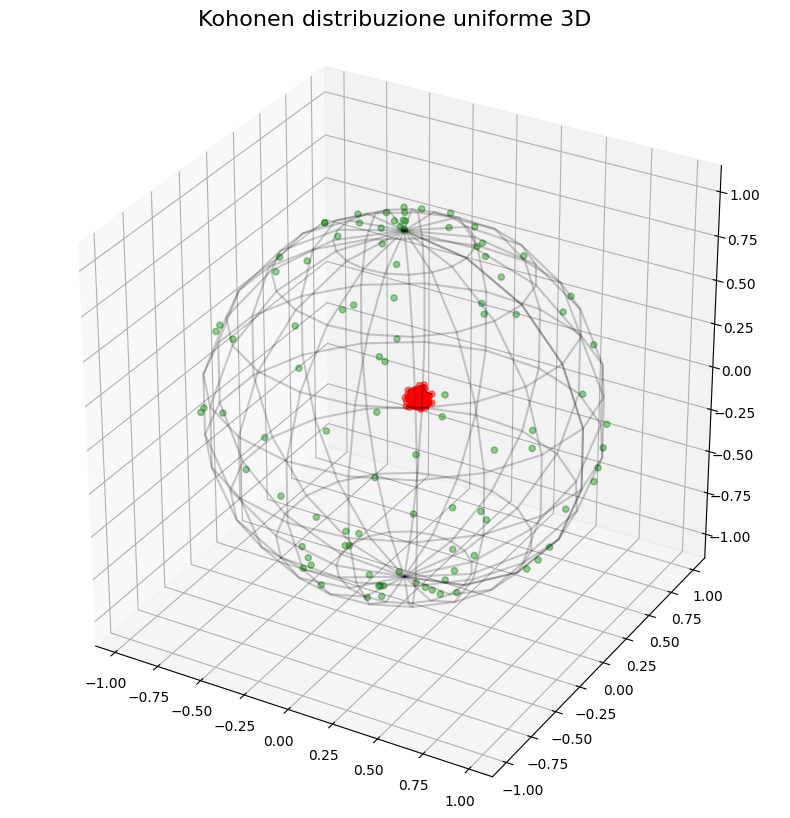

In [ ]:
#creo un'animazione dell'apprendimento

fig = plt.figure(figsize=(10,10));
ax = fig.add_subplot(projection='3d');

nframes =  w_0_t.shape[2]

def update_figure(k):
    w_0p = w_0_t[:,:,k]
    w_1p = w_1_t[:,:,k]
    w_2p = w_2_t[:,:,k]
    # draw the network
    ax.clear()
    ax.scatter(xtest,ytest,ztest, c='g',alpha=0.4)
    ax.scatter(w_0p,w_1p,w_2p, c='r',marker='o',alpha=0.5)
    for i in range(n):
        ax.plot(w_0p[i,:],w_1p[i,:],w_2p[i,:],'k',linewidth=1)
        ax.plot(w_0p[:,i],w_1p[:,i],w_2p[:,i],'k',linewidth=1)
    ax.set_title('Kohonen distribuzione uniforme 3D',fontsize=16)
    ax.set_box_aspect([1,1,1])
    #creo una griglia sferica
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    x = np.cos(u) * np.sin(v)
    y = np.sin(u) * np.sin(v)
    z = np.cos(v)

    # Plot the sphere
    ax.plot_wireframe(x, y, z, color='black', alpha = 0.2)
    return ax

#%%
print("\n**** Generando l'animazione ****\n")

anim = animation.FuncAnimation(fig, func=update_figure, frames=nframes,
                               repeat=False);

# create a video writer
writervideo = animation.FFMpegWriter(fps=7)
anim.save('/content/kohonen_2D_over_3D_animated.mp4', writer=writervideo)
# %%
print("\n*** Animazione completa ***\n")
